# Optimización Multiobjetivo y Frentes de Pareto (NSGA-II)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/08_optimizacion_multiobjetivo_nsga2.ipynb)

## Objetivos


- Comprender por qué el enfoque clásico de "Suma Ponderada" falla en problemas de ingeniería reales.
- Dominar los conceptos matemáticos de **Dominancia de Pareto** y **Frente de Pareto**.
- Entender la mecánica interna del algoritmo **NSGA-II** (*Non-dominated Sorting* y *Crowding Distance*).
- Implementar NSGA-II en DEAP para resolver un benchmark clásico (ZDT1) y un problema de diseño mecánico real (Viga en I).



## Prerrequisitos


- Haber completado: [Introducción a DEAP: Infraestructura Evolutiva en Python](03_framework_deap_y_paralelizacion.ipynb).
- Nociones de *trade-offs* en ingeniería (ej. Costo vs. Calidad).

---


## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

try:
    import deap
except ImportError:
    !pip install deap
from deap import base, creator, tools

# Fijamos la semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 19.1 MB/s eta 0:00:00


## Introducción Teórica: Fin de la Suma Ponderada?


En los notebooks anteriores, optimizamos un único objetivo (ej. minimizar el error, maximizar el *accuracy*). Pero, en la ingeniería real, **casi nunca optimizamos un solo objetivo**.
- Un puente debe ser barato **Y** resistente.
- Un modelo de IA debe ser preciso **Y** rápido.

Mejorar uno casi siempre empeora el otro.
El enfoque clásico de "suma ponderada" (lo que venimos realizando en notebooks anteriores) obliga a decidir los pesos antes de conocer las soluciones posibles. Peor aún: en muchos paisajes reales, este método es matemáticamente incapaz de encontrar los mejores compromisos.
La solución es dejar de sumar objetivos y empezar a pensar en **Frentes de Pareto**.

Ahora lo vemos con más detalle...

### La Trampa del Enfoque Escalar


Históricamente, estos problemas se resolvían (y resuelven) sumando los objetivos con pesos:

$$ \text{Fitness} = w_1 \cdot \text{Costo} + w_2 \cdot \text{Error} $$

> **Peligros de la Suma Ponderada:**
> 1. **Subjetividad:** Requiere decidir los pesos ($w_1, w_2$) *antes* de conocer qué opciones existen. ¿Cuánto vale exactamente 1 milisegundo de latencia en términos de error de predicción?
> 2. **Ceguera Matemática:** Si el límite de las soluciones posibles (el Frente de Pareto) tiene una forma cóncava, **ninguna combinación de pesos matemáticamente posible** encontrará las soluciones que están en la concavidad. El algoritmo será ciego a los mejores compromisos.


### La Solución: Dominancia de Pareto



En lugar de sumar peras con manzanas, evaluamos los objetivos por separado usando la regla de **Dominancia de Pareto**:
*La solución A domina a la solución B si A es igual o mejor que B en TODOS los objetivos, y estrictamente mejor en al menos UNO.*

Si una solución no es dominada por ninguna otra en toda la población, decimos que pertenece al **Frente de Pareto**. Nuestro objetivo ya no es encontrar "un punto", sino encontrar toda la curva del Frente de Pareto para que el ingeniero (el que conoce los requerimientos del problema que se está abordando) pueda elegir visual/informadamente el mejor *trade-off*.


## Algoritmo NSGA-II



Propuesto por Deb et al. en 2002, el *Non-dominated Sorting Genetic Algorithm II* es el estándar absoluto de la industria para 2 o 3 objetivos. Funciona con dos mecánicas:

1.  **Non-dominated Sorting (Clasificación por Frentes):** El algoritmo toma a toda la población y extrae a los individuos no dominados. A estos les asigna el "Frente 1" (los mejores). Luego los quita, y a los no dominados restantes les asigna el "Frente 2", y así sucesivamente.
2.  **Crowding Distance (Distancia de Aglomeración):** Si tenemos que elegir entre dos individuos que están en el mismo Frente, ¿con cuál nos quedamos? NSGA-II calcula qué tan "aislado" está cada individuo. Premia a los que están en zonas vacías y penaliza a los que están aglomerados. **Esto garantiza que el Frente de Pareto se expanda y cubra todas las opciones posibles sin usar parámetros mágicos de nicho.**


## Desarrollo e Implementación: Benchmark ZDT1



Vamos a probar NSGA-II en **ZDT1**, una función de benchmark clásica para multiobjetivo. Tiene 30 variables de entrada y 2 objetivos a minimizar. El Frente de Pareto real tiene una forma convexa conocida: $f_2 = 1 - \sqrt{f_1}$.



### 1. Configuración de DEAP para Multiobjetivo


In [2]:
# Limpiamos el entorno
for cls in ['FitnessMulti', 'Individual']:
    if hasattr(creator, cls): delattr(creator, cls)

# 1. Fitness Multiobjetivo: Queremos MINIMIZAR ambos objetivos
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# 2. Definimos el problema ZDT1
DIMENSIONES = 30

def zdt1(individuo):
    """Benchmark ZDT1: 2 objetivos a minimizar."""
    x = np.array(individuo)
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (DIMENSIONES - 1)
    h = 1.0 - np.sqrt(f1 / g)
    f2 = g * h
    return (f1, f2)

tb_zdt = base.Toolbox()
tb_zdt.register("attr_float", random.uniform, 0.0, 1.0)
tb_zdt.register("individual", tools.initRepeat, creator.Individual, tb_zdt.attr_float, n=DIMENSIONES)
tb_zdt.register("population", tools.initRepeat, list, tb_zdt.individual)
tb_zdt.register("evaluate", zdt1)

# 3. Operadores Estándar para NSGA-II en espacios continuos
# SBX (Simulated Binary Crossover) y Mutación Polinomial son el estándar de facto.
tb_zdt.register("mate", tools.cxSimulatedBinaryBounded, low=0.0, up=1.0, eta=20.0)
tb_zdt.register("mutate", tools.mutPolynomialBounded, low=0.0, up=1.0, eta=20.0, indpb=1.0/DIMENSIONES)

# 4. Selección NSGA-II
tb_zdt.register("select", tools.selNSGA2)

### 2. Bucle Evolutivo de NSGA-II



A diferencia del GA clásico, NSGA-II requiere que los padres y los hijos se unan en una "súper-población" de tamaño $2N$. Luego, el operador `selNSGA2` extrae a los mejores $N$ individuos para la siguiente generación. Escribimos este bucle a mano.



In [3]:
N_POP = 100
N_GEN = 100

pop = tb_zdt.population(n=N_POP)

# Evaluación inicial
for ind in pop:
    ind.fitness.values = tb_zdt.evaluate(ind)

# Asignamos el Crowding Distance inicial
pop = tb_zdt.select(pop, len(pop))

historia_frentes = []

print("Ejecutando NSGA-II en ZDT1...")
for gen in range(N_GEN):
    # Guardamos el frente actual para la visualización
    frente_actual = np.array([ind.fitness.values for ind in pop])
    historia_frentes.append(frente_actual)

    # 1. Selección de padres (Torneo basado en Dominancia y Crowding Distance)
    offspring = tools.selTournamentDCD(pop, len(pop))
    offspring = list(map(tb_zdt.clone, offspring))

    # 2. Cruce y Mutación
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.9:
            tb_zdt.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        if random.random() < 0.2:
            tb_zdt.mutate(mutant)
            del mutant.fitness.values

    # 3. Evaluación de hijos
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid_ind:
        ind.fitness.values = tb_zdt.evaluate(ind)

    # 4. Reemplazo NSGA-II (Elitismo estricto: Padres + Hijos)
    pop = tb_zdt.select(pop + offspring, N_POP)

# Guardamos la última generación
historia_frentes.append(np.array([ind.fitness.values for ind in pop]))
print("Evolución terminada.")

Ejecutando NSGA-II en ZDT1...
Evolución terminada.


### 3. Visualización de la Evolución del Frente



Veamos cómo la población (una nube de puntos aleatoria) es "empujada" hacia el límite teórico inferior izquierdo.



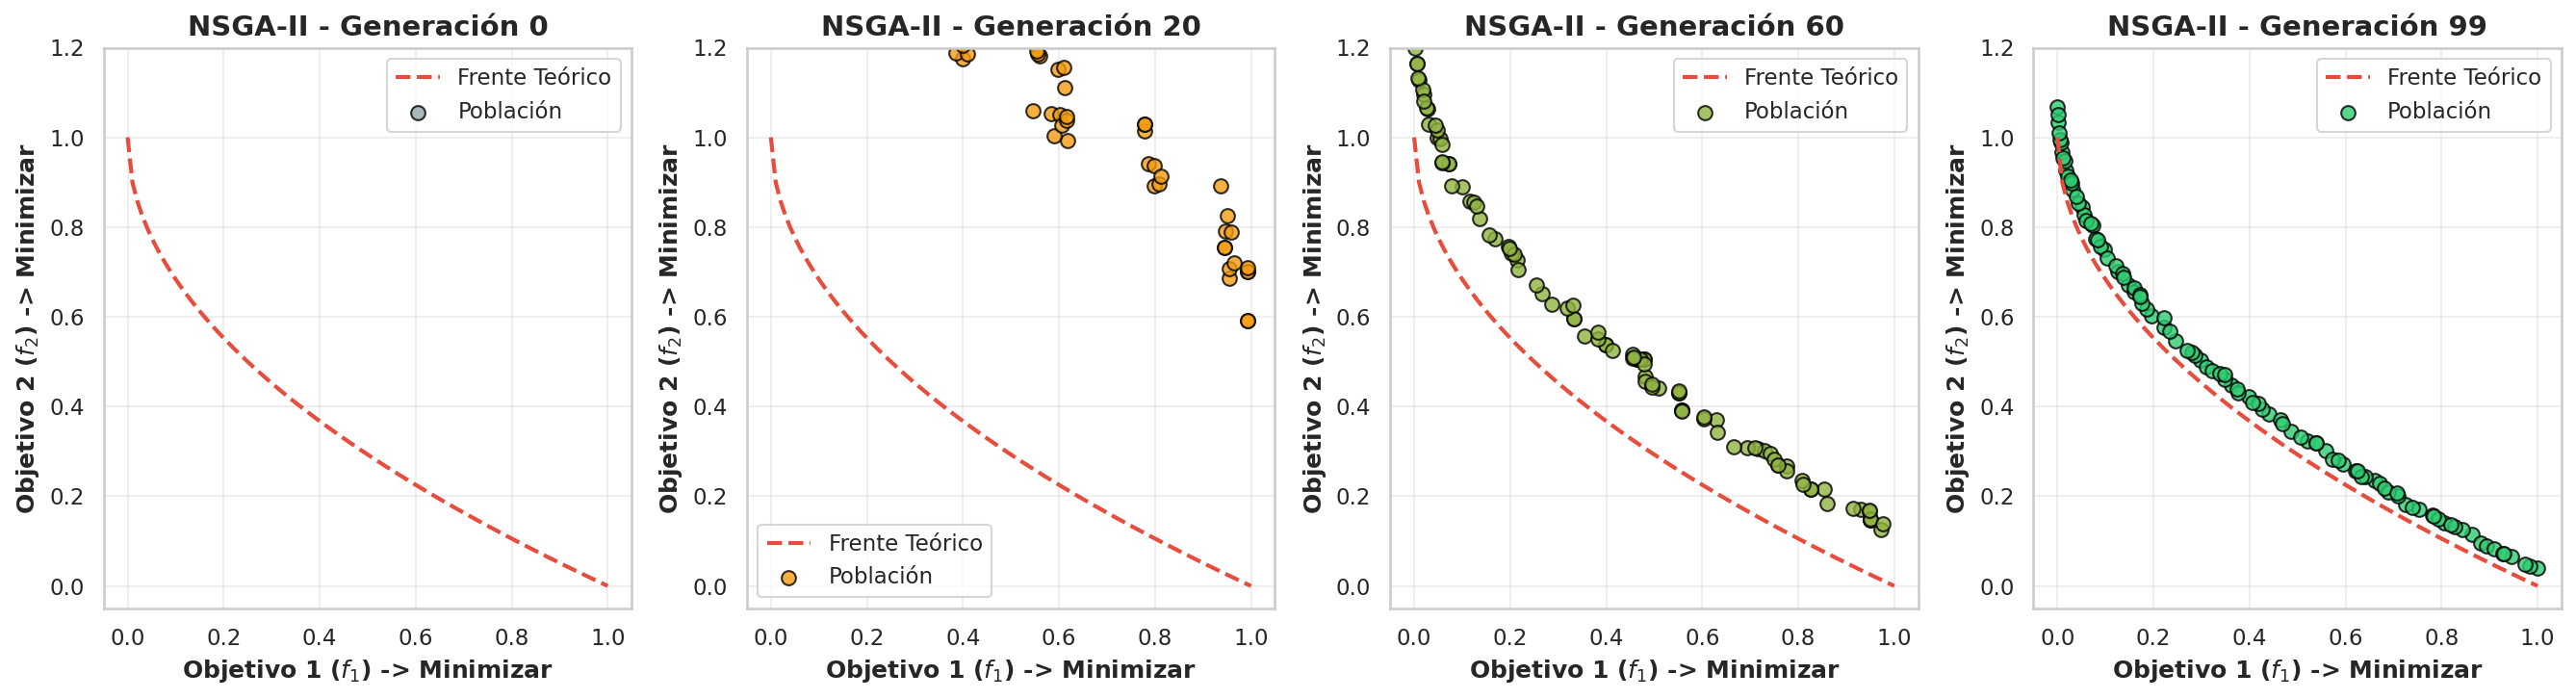

In [4]:
# Frente de Pareto Teórico de ZDT1
f1_teorico = np.linspace(0, 1, 100)
f2_teorico = 1 - np.sqrt(f1_teorico)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
generaciones_plot = [0, 20, 60, 99]
colores = ['#95a5a6', '#f39c12', '#91b442', '#2ecc71']

for ax, gen, color in zip(axes, generaciones_plot, colores):
    pts = historia_frentes[gen]

    ax.plot(f1_teorico, f2_teorico, color='#e74c3c', lw=2, linestyle='--', label='Frente Teórico')
    ax.scatter(pts[:, 0], pts[:, 1], color=color, edgecolor='black', s=50, alpha=0.8, label='Población')

    ax.set_title(f"NSGA-II - Generación {gen}")
    ax.set_xlabel("Objetivo 1 ($f_1$) -> Minimizar")
    ax.set_ylabel("Objetivo 2 ($f_2$) -> Minimizar")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.2)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


> **Análisis Visual:** Observar la Generación 0. Los puntos están dispersos y lejos del óptimo (ni siquiera aparecen). En la Generación 20, la población ya se ha acercado al frente, pero está aglomerada en ciertas zonas. Sigue "avanzando" de forma cada vez "más organizada". En la Generación 99, gracias al *Crowding Distance*, los puntos se han distribuido de manera "perfectamente" uniforme a lo largo de toda la curva teórica roja.

### 4. Métricas de Calidad del Frente de Pareto

Tener un Frente de Pareto visualmente lindo no es suficiente. Para problemas duros, necesitamos **métricas cuantitativas** para evaluar cuán bueno es realmente el frente encontrado por NSGA-II y compararlo con otras ejecuciones o algoritmos. Así que las abordo de manera muy acotada, para saber que existen...

Las más importantes en optimización multi-objetivo son:

#### 1. **Hypervolume (HV)** — La más utilizada



Mide el **volumen** (en 2D es área) del espacio dominado por el Frente de Pareto respecto a un punto de referencia (generalmente el "peor caso posible").  
**Mayor Hypervolume = Mejor frente** (mejor convergencia + mejor diversidad).


In [5]:
def hypervolume(front, ref_point):
    """Calcula Hypervolume aproximado para 2 objetivos (minimización)."""
    front = np.array(front)
    front = front[np.argsort(front[:, 0])]  # Ordenar por f1
    hv = 0.0
    for i in range(len(front)):
        hv += (ref_point[0] - front[i, 0]) * (ref_point[1] - front[i-1, 1] if i > 0 else (ref_point[1] - front[i, 1]))
    return hv


#### 2. **Spacing (ESP)** — Uniformidad


Mide cuán equidistantes están los puntos entre sí. Un frente ideal debe estar bien distribuido (no aglomerado en una zona dejando otras desatendidas).


In [6]:
def spacing(front):
    """Mide uniformidad del frente (menor = mejor)."""
    front = np.array(front)
    distances = []
    for i in range(len(front)):
        dist_to_others = np.min(np.sqrt(np.sum((front - front[i])**2, axis=1)))
        distances.append(dist_to_others)
    return np.std(distances)


#### 3. **Spread (Δ)** — Cobertura


Mide cuán bien el frente cubre el rango completo de los objetivos (desde el mejor valor de f1 hasta el mejor valor de f2).

In [7]:
from scipy.spatial.distance import pdist

def spread(front):
    """Mide cobertura del frente (menor = mejor)."""
    front = np.array(front)
    d_f1 = np.min(front[:, 0])  # Mejor f1
    d_f2 = np.min(front[:, 1])  # Mejor f2
    extreme1 = np.min(np.sqrt((front[:, 0] - d_f1)**2 + (front[:, 1] - front[:, 1].max())**2))
    extreme2 = np.min(np.sqrt((front[:, 0] - front[:, 0].max())**2 + (front[:, 1] - d_f2)**2))
    mean_dist = np.mean(pdist(front))
    delta = (extreme1 + extreme2 + np.sum(np.abs(pdist(front) - mean_dist))) / (extreme1 + extreme2 + (len(front)-1)*mean_dist)
    return delta

Para los individuos al final de la evolución, los valores son:

In [8]:
# --- Cálculo para nuestro Frente de Pareto ---
frente_array = np.array([ind.fitness.values for ind in pop])

# Punto de referencia (peor caso posible)
ref_point = [np.max(frente_array[:,0]) + 10, np.max(frente_array[:,1]) + 10]

hv = hypervolume(frente_array, ref_point)
sp = spacing(frente_array)
spr = spread(frente_array)

print("--- Métricas de Calidad del Frente de Pareto ---")
print(f"Hypervolume (mayor es mejor): {hv:.2f}")
print(f"Spacing (menor es mejor - uniformidad): {sp:.4f}")
print(f"Spread (menor es mejor - cobertura): {spr:.4f}")

--- Métricas de Calidad del Frente de Pareto ---
Hypervolume (mayor es mejor): 11198.53
Spacing (menor es mejor - uniformidad): 0.0000
Spread (menor es mejor - cobertura): 28.8507


**Interpretación**

- **Hypervolume alto** → El frente es bueno tanto en convergencia (cerca del óptimo) como en diversidad (bien distribuido).
- **Spacing bajo** → Los puntos están bien espaciados. No hay aglomeraciones ni huecos grandes.
- **Spread bajo** → El frente cubre bien todo el rango de trade-offs posibles.

> **Criterio de Ingeniería**:  
Reportar estas métricas al final de una corrida de NSGA-II. Si el Hypervolume es bajo o el Spacing es alto, significa que el algoritmo no exploró suficientemente o que los hiperparámetros (`eta`, probabilidades de cruce/mutación) necesitan ajuste. *Esto abre el camino para criterios de parada temprana...*

## Mini Caso de Estudio: Diseño de una Viga en I (I-Beam)



Salimos de las matemáticas abstractas y vamos a la ingeniería mecánica. Queremos diseñar el perfil de una Viga en I de acero (*ba, siguen las matemáticas*).

**Variables de Diseño (Genotipo):**
1.  $b$: Ancho del ala ($10$ a $50$ cm).
2.  $h$: Altura total ($10$ a $80$ cm).
3.  $t_w$: Espesor del alma ($0.5$ a $5$ cm).
4.  $t_f$: Espesor del ala ($0.5$ a $5$ cm).

**Objetivos (En conflicto):**
*   **$f_1$ (Costo/Peso):** Minimizar el Área Transversal ($A$).
*   **$f_2$ (Flexibilidad):** Minimizar la Deflexión ($\delta$) bajo una carga $P$. (Equivale a maximizar la rigidez).

**Restricciones Físicas:**
*   El esfuerzo máximo ($\sigma$) no puede superar el límite de fluencia del acero ($S_{max} = 300$ MPa). Si lo supera, aplicamos una **Penalización Suave** a ambos objetivos. Para geometrías imposibles, aplicamos **Penalización Dura**.



In [9]:
# Parámetros físicos

P = 600000    # N (Carga puntual)
L = 200       # cm (Longitud)
E = 2e7       # N/cm² (Módulo de Young)
S_MAX = 30000 # N/cm² (Límite de fluencia: 300 MPa = 30.000 N/cm²)

# NOTA: cuidado con las unidades, todo debe de ser coherente para que las ecuaciones tengan sentido físico...

def evaluar_viga(individuo):
    x = np.asarray(individuo)
    b, h, tw, tf = x[0], x[1], x[2], x[3]

    # 1. Validación Geométrica Estricta
    # El espesor de las alas no puede superar la altura, y el alma no puede ser más ancha que el ala
    if 2 * tf >= h or tw >= b:
        return (1e6, 1e6) # Penalización fuerte por geometría imposible

    # 2. Calculamos el Área (Objetivo 1: Costo/Peso)
    area = 2 * b * tf + (h - 2 * tf) * tw

    # 3. Calculamos el Momento de Inercia (Iz)
    iz = (b * h**3 - (b - tw) * (h - 2 * tf)**3) / 12.0

    if iz <= 0 or area <= 0:
        return (1e6, 1e6)

    # 4. Calculamos la Deflexión (Objetivo 2: Flexibilidad)
    deflexion = (P * L**3) / (48 * E * iz)

    # 5. Calculamos el Esfuerzo (Restricción)
    esfuerzo = (P * L * (h / 2)) / (4 * iz)

    # Penalización Suave y Escalada
    penalizacion = 0.0
    if esfuerzo > S_MAX:
        # Penalizamos proporcionalmente al exceso
        penalizacion += ((esfuerzo - S_MAX) / S_MAX) * 1000

    return (area + penalizacion, deflexion + penalizacion)

# Configuración DEAP para la Viga
tb_viga = base.Toolbox()
LIMITES_LOW = [10.0, 10.0, 0.5, 0.5]
LIMITES_UP = [50.0, 80.0, 5.0, 5.0]

def generar_viga():
    return creator.Individual([random.uniform(l, u) for l, u in zip(LIMITES_LOW, LIMITES_UP)])

tb_viga.register("individual", generar_viga)
tb_viga.register("population", tools.initRepeat, list, tb_viga.individual)
tb_viga.register("evaluate", evaluar_viga)
tb_viga.register("mate", tools.cxSimulatedBinaryBounded, low=LIMITES_LOW, up=LIMITES_UP, eta=20.0)
tb_viga.register("mutate", tools.mutPolynomialBounded, low=LIMITES_LOW, up=LIMITES_UP, eta=20.0, indpb=0.25)
tb_viga.register("select", tools.selNSGA2)

# Ejecución
pop_viga = tb_viga.population(n=100)
for ind in pop_viga: ind.fitness.values = tb_viga.evaluate(ind)
pop_viga = tb_viga.select(pop_viga, len(pop_viga))

for gen in range(100):
    offspring = tools.selTournamentDCD(pop_viga, len(pop_viga))
    offspring = list(map(tb_viga.clone, offspring))
    for c1, c2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.9:
            tb_viga.mate(c1, c2)
            del c1.fitness.values; del c2.fitness.values
    for mut in offspring:
        if random.random() < 0.2:
            tb_viga.mutate(mut)
            del mut.fitness.values
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid_ind: ind.fitness.values = tb_viga.evaluate(ind)
    pop_viga = tb_viga.select(pop_viga + offspring, 100)

# Extraemos el Frente de Pareto final
frente_pareto = tools.sortNondominated(pop_viga, len(pop_viga), first_front_only=True)[0]
areas = [ind.fitness.values[0] for ind in frente_pareto]
deflexiones = [ind.fitness.values[1] for ind in frente_pareto]

### Toma de Decisiones: Leyendo el Frente de Pareto



El algoritmo ha terminado. No nos devolvió "una" viga, nos devolvió un menú de opciones óptimas. Como ingenieros, ¿cuál elegimos?



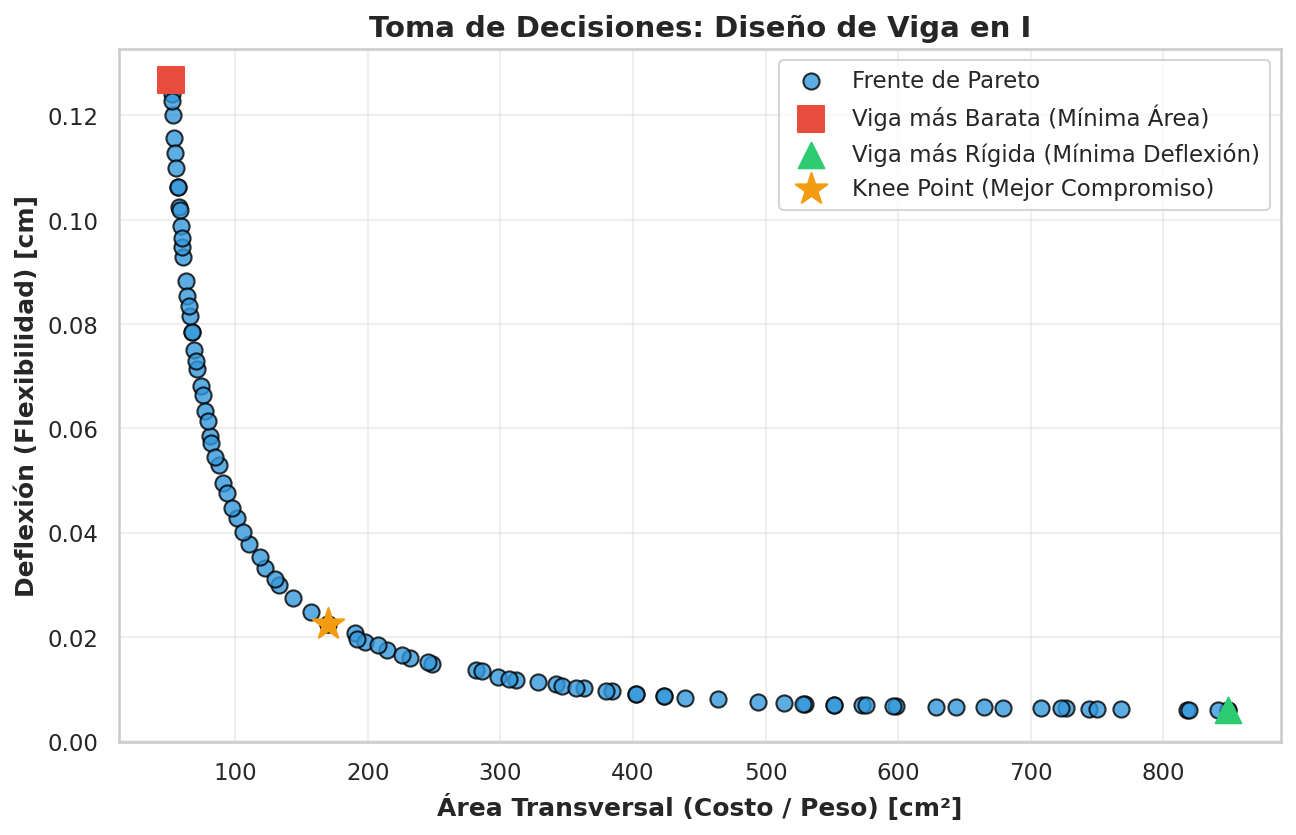

--- Opciones de Diseño ---
1. Viga más Barata: Área = 51.8 cm², Deflexión = 0.1267 cm
2. Viga más Rígida: Área = 849.1 cm², Deflexión = 0.0059 cm
3. Knee Point:      Área = 170.3 cm², Deflexión = 0.0224 cm


In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(areas, deflexiones, color='#3498db', edgecolor='black', s=60, alpha=0.8, label='Frente de Pareto')

# Identificamos puntos clave
idx_min_area = np.argmin(areas)
idx_min_deflexion = np.argmin(deflexiones)

# El "Knee Point" (Punto de Inflexión) suele ser el punto más cercano al origen ideal
# Normalizamos los objetivos para calcular la distancia justa
areas_norm = (areas - np.min(areas)) / (np.max(areas) - np.min(areas))
deflex_norm = (deflexiones - np.min(deflexiones)) / (np.max(deflexiones) - np.min(deflexiones))
distancias_origen = np.sqrt(areas_norm**2 + deflex_norm**2)
idx_knee = np.argmin(distancias_origen)

plt.scatter(areas[idx_min_area], deflexiones[idx_min_area], color='#e74c3c', s=150, marker='s', label='Viga más Barata (Mínima Área)')
plt.scatter(areas[idx_min_deflexion], deflexiones[idx_min_deflexion], color='#2ecc71', s=150, marker='^', label='Viga más Rígida (Mínima Deflexión)')
plt.scatter(areas[idx_knee], deflexiones[idx_knee], color='#f39c12', s=250, marker='*', label='Knee Point (Mejor Compromiso)')

plt.title("Toma de Decisiones: Diseño de Viga en I")
plt.xlabel("Área Transversal (Costo / Peso) [cm²]")
plt.ylabel("Deflexión (Flexibilidad) [cm]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("--- Opciones de Diseño ---")
print(f"1. Viga más Barata: Área = {areas[idx_min_area]:.1f} cm², Deflexión = {deflexiones[idx_min_area]:.4f} cm")
print(f"2. Viga más Rígida: Área = {areas[idx_min_deflexion]:.1f} cm², Deflexión = {deflexiones[idx_min_deflexion]:.4f} cm")
print(f"3. Knee Point:      Área = {areas[idx_knee]:.1f} cm², Deflexión = {deflexiones[idx_knee]:.4f} cm")


> 💡 **El Valor del Ingeniero:** El algoritmo hizo el trabajo pesado de descartar millones de vigas ineficientes. Ahora, el ingeniero de proyectos toma la decisión final:
> * Si el presupuesto es ajustado, elegirá la viga roja.
> * Si la viga soportará un puente crítico, elegirá la viga verde.
> * Si busca el mejor balance general, elegirá la estrella amarilla (el *Knee Point*), donde ganar un poco más de rigidez empezaría a costar muchísimo más acero.

*Como siempre, el contexto y la problemática determinan cuál es la solución viable y qué es "lo mejor"...*

### Exportación de Resultados para Producción

En un entorno industrial, el Frente de Pareto se exportaría para que otros departamentos (Finanzas, Manufactura, etc.) puedan analizar las opciones en sus propias herramientas (el típico Excel por ej.). Va pequeño ejemplo, esto se vincula nuevamente con el EDA de los inicios de todo este recorrido.

In [11]:
import pandas as pd

# Creamos un DataFrame con las variables de diseño y los objetivos
df_pareto = pd.DataFrame({
    'b_cm': [ind[0] for ind in frente_pareto],
    'h_cm': [ind[1] for ind in frente_pareto],
    'tw_cm': [ind[2] for ind in frente_pareto],
    'tf_cm': [ind[3] for ind in frente_pareto],
    'Area_cm2': areas,
    'Deflexion_cm': deflexiones
})

# Ordenamos por Área (Costo)
df_pareto = df_pareto.sort_values(by='Area_cm2').reset_index(drop=True)

# Exportamos a CSV
df_pareto.to_csv('frente_pareto_viga.csv', index=False)
print("Frente de Pareto exportado a 'frente_pareto_viga.csv'")
display(df_pareto.head())

Frente de Pareto exportado a 'frente_pareto_viga.csv'


,b_cm,h_cm,tw_cm,tf_cm,Area_cm2,Deflexion_cm
0,12.760501,78.869614,0.500011,0.504991,51.818582,0.126732
1,12.760501,78.869614,0.500011,0.504991,51.818582,0.126732
2,12.760501,78.869614,0.501429,0.504991,51.928929,0.126553
3,12.590729,79.772913,0.500592,0.503075,52.098137,0.124110
4,12.760501,79.881516,0.500058,0.504851,52.324782,0.122727


**¿Por qué no usar Suma Ponderada en este tipo de problemas?**

Si hubiéramos usado un GA clásico minimizando $Fitness = 0,5 \cdot \text{Area} + 0,5 \cdot \text{Deflexion}$, el algoritmo habría convergido a **un solo punto** de la gráfica anterior. Si el gerente de proyecto luego nos pidiera "una opción un poco más barata aunque flexione más", tendríamos que cambiar los pesos (ej. $0,8$ y $0,2$) y **volver a correr todo el algoritmo desde cero**.
NSGA-II nos dio *todas* las opciones posibles en una sola corrida.

## Limitaciones de NSGA-II y el Futuro (NSGA-III)

NSGA-II funciona excelente con 2 o 3 objetivos. Sin embargo, cuando tenemos 4 o más (ej. Costo, Peso, Tiempo de Fabricación, Impacto Ambiental, Fiabilidad), ocurre un fenómeno matemático conocido como la **Maldición de la Dimensionalidad Multiobjetivo**.

En espacios de alta dimensión, casi toda la población se vuelve "no dominada" (es muy fácil ser mejor que otro en al menos 1 de 5 objetivos). El Frente se convierte en una nube difusa, el *Crowding Distance* pierde sentido y el algoritmo pierde su presión selectiva.

Para estos casos, la industria usa **NSGA-III** (o MOEA/D), que reemplaza el *Crowding Distance* por un conjunto de **puntos de referencia** distribuidos uniformemente en el espacio objetivo, guiando a la población hacia esos vectores específicos.

## Conexiones y Próximos Pasos


Hasta ahora, asumimos que nuestra población siempre evoluciona junta en un solo "continente". Pero, ¿qué pasa si el paisaje de fitness es tan complejo que toda la población se queda igualmente atrapada en un óptimo local masivo?

En el próximo notebook, aprendemos a dividir nuestra población en islas separadas, permitiendo que evolucionen "culturas" distintas y "compartan" sus mejores descubrimientos mediante la migración.

- ➡️ **Siguiente:** [Modelos de Islas y Mantenimiento de Diversidad](09_modelos_de_islas_y_diversidad.ipynb)
- 🔄 **Relacionado:** [Programación Genética (GP): Evolucionando Estructuras y Ecuaciones](07_programacion_genetica_gp.ipynb)



## Referencias


### Artículos Fundacionales

1. **Deb, K., Pratap, A., Agarwal, S., & Meyarivan, T. (2002)**. *A fast and elitist multiobjective genetic algorithm: NSGA-II*. IEEE Transactions on Evolutionary Computation, 6(2), 182-197.  
   (**Paper original de NSGA-II**).

2. **Deb, K., & Jain, H. (2014)**. *An Evolutionary Many-Objective Optimization Algorithm Using Reference-Point-Based Nondominated Sorting Approach, Part I: Solving Problems With Box Constraints*. IEEE Transactions on Evolutionary Computation.  
   (NSGA-III — solución para muchos objetivos).

3. **Zitzler, E., & Thiele, L. (1999)**. *Multiobjective evolutionary algorithms: a comparative case study and the strength Pareto approach*. IEEE Transactions on Evolutionary Computation. (Introdujo el concepto de Hypervolume).

### Recursos Práctico

- **Deb, K. (2001)**. *Multi-Objective Optimization using Evolutionary Algorithms*. Wiley. (**Libro de referencia** del autor de NSGA-II).
- **DEAP** — [Ejemplo oficial NSGA-III](https://deap.readthedocs.io/en/master/examples/nsga3.html)
- **Pymoo** — Framework moderno de Python con implementaciones de NSGA-II, NSGA-III, MOEA/D y visualizaciones avanzadas. Algunos ejemplos: [Convergencia utilizando el *Hypervolume*](https://pymoo.org/getting_started/part_4.html#Pareto-front-is-unknown), [Lista de Algoritmos](https://pymoo.org/algorithms/list.html#nb-algorithms-list)
- **Platypus** — Framework especializado en multi-objetivo. [Experimentador para múltiples algoritmos](https://platypus.readthedocs.io/en/latest/experimenter.html#comparing-algorithms-visually)

---


## Entorno de Ejecución


In [12]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
deap,1.4
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
